# Drone RL Navigation — Training Analysis

This notebook provides end-to-end analysis of the PPO training run:
- Reward curves & convergence
- Reward component breakdown
- Goal-success and collision-rate trends
- 3-D flight trajectory visualisation
- Evaluation statistics

In [1]:
import sys, os
from pathlib import Path

# Make imports work whether notebook is started from project root or notebooks/
cwd = Path.cwd()
if (cwd / "utils").exists():
    project_root = cwd
elif (cwd.parent / "utils").exists():
    project_root = cwd.parent
else:
    project_root = cwd

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from utils.visualization import (
    plot_training_rewards,
    plot_reward_components,
    plot_episode_trajectory,
    plot_evaluation_summary,
    plot_sensor_heatmap,
)
from config.env_config import ENV_CONFIG
from config.training_config import TRAIN_CONFIG

print('Imports OK')
print(f'Project root: {project_root}')



Imports OK
Project root: /Volumes/Fire/Drone - RL - Navigation


## 1. Load Training Logs

In [2]:
from pathlib import Path
import pandas as pd

# 1) Prefer non-empty CSV logs when available
csv_candidates = list(Path("logs").glob("run_*.csv")) + list(Path("../logs").glob("run_*.csv"))
csv_candidates = sorted([p for p in csv_candidates if p.exists() and p.stat().st_size > 0])

if csv_candidates:
    log_csv = csv_candidates[-1]
    print(f"Using CSV log: {log_csv}")
    df = pd.read_csv(log_csv)
    print(f"Loaded {len(df)} rows")
    display(df.head())
else:
    # 2) Fallback: read TensorBoard event files (common in this project)
    tb_events = sorted(Path("logs/tensorboard").glob("**/events.out.tfevents.*"))
    if not tb_events:
        tb_events = sorted(Path("../logs/tensorboard").glob("**/events.out.tfevents.*"))

    if not tb_events:
        print("No CSV or TensorBoard events found. Run training first.")
        df = pd.DataFrame()
    else:
        try:
            from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

            # Pick a run that actually has scalar tags.
            chosen = None
            chosen_tags = []
            for ev in reversed(tb_events):
                ea_try = EventAccumulator(str(ev.parent))
                ea_try.Reload()
                tags_try = ea_try.Tags().get("scalars", [])
                if "rollout/ep_rew_mean" in tags_try:
                    chosen = (ev, ea_try)
                    chosen_tags = tags_try
                    break
                if tags_try and chosen is None:
                    chosen = (ev, ea_try)
                    chosen_tags = tags_try

            if chosen is None:
                print("TensorBoard files found, but no scalar tags are available yet.")
                df = pd.DataFrame()
            else:
                chosen_event, ea = chosen
                print(f"CSV not available. Reading TensorBoard event: {chosen_event}")

                if "rollout/ep_rew_mean" in chosen_tags:
                    scalars = ea.Scalars("rollout/ep_rew_mean")
                    df = pd.DataFrame(
                        {
                            "step": [s.step for s in scalars],
                            "episode/total_reward": [s.value for s in scalars],
                        }
                    )
                    print(f"Loaded {len(df)} reward points from TensorBoard")
                    display(df.head())
                else:
                    print("TensorBoard loaded, but 'rollout/ep_rew_mean' not found.")
                    print(f"Available scalar tags: {chosen_tags[:12]}")
                    df = pd.DataFrame()
        except Exception as e:
            print(f"Failed to parse TensorBoard event file: {e}")
            df = pd.DataFrame()



CSV not available. Reading TensorBoard event: ../logs/tensorboard/PPO_drone_4/events.out.tfevents.1774772493.Chandans-Mac-mini.local.12855.1
Loaded 245 reward points from TensorBoard


,step,episode/total_reward
0,2048,-118.809044
1,4096,-94.447037
2,6144,-69.842789
3,8192,-127.895805
4,10240,-104.537842


## 2. Reward Curve

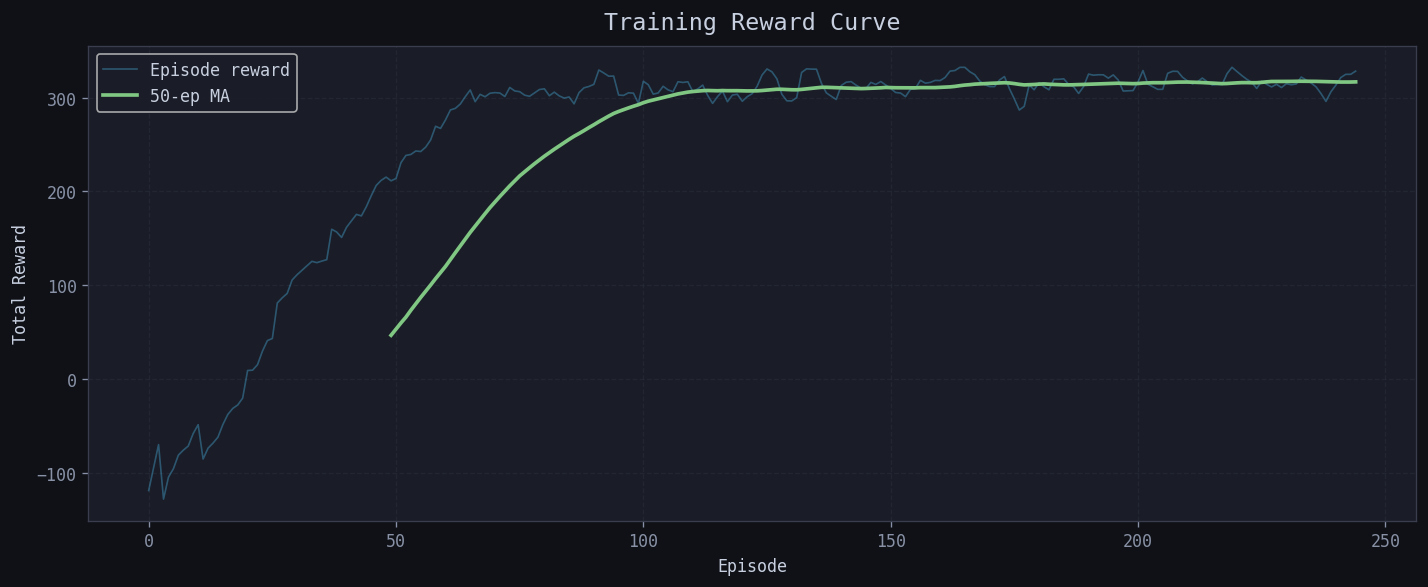

In [3]:
# Ensure plotting helper is available even when cells run out of order
try:
    plot_training_rewards
except NameError:
    import sys
from pathlib import Path
cwd = Path.cwd()
if (cwd / "utils").exists():
    root = cwd
elif (cwd.parent / "utils").exists():
    root = cwd.parent
else:
    root = cwd
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.visualization import plot_training_rewards

if 'episode/total_reward' in df.columns:
    rewards = df['episode/total_reward'].dropna().tolist()
    fig = plot_training_rewards(rewards, window=50, title="Training Reward Curve")
    plt.show()
else:
    # Demo with synthetic data
    np.random.seed(42)
    synthetic = np.cumsum(np.random.randn(500)) - np.linspace(50, -100, 500)
    fig = plot_training_rewards(synthetic.tolist(), window=50, title="Synthetic Demo Curve")
    plt.show()



## 3. Goal-Success & Collision Rate

In [4]:
if 'episode/goal_reached' in df.columns:
    window = 50
    goal_rate  = df['episode/goal_reached'].rolling(window).mean()
    crash_rate = df['episode/collision'].rolling(window).mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(goal_rate.values,  label='Goal rate',      color='#81c784', lw=2)
    ax.plot(crash_rate.values, label='Collision rate', color='#f06292', lw=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Rate (rolling 50-ep)')
    ax.set_title('Goal Success vs Collision Rate')
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.show()
else:
    print("No episode/goal_reached column found — run training to generate logs.")

No episode/goal_reached column found — run training to generate logs.


## 4. Reward Component Breakdown

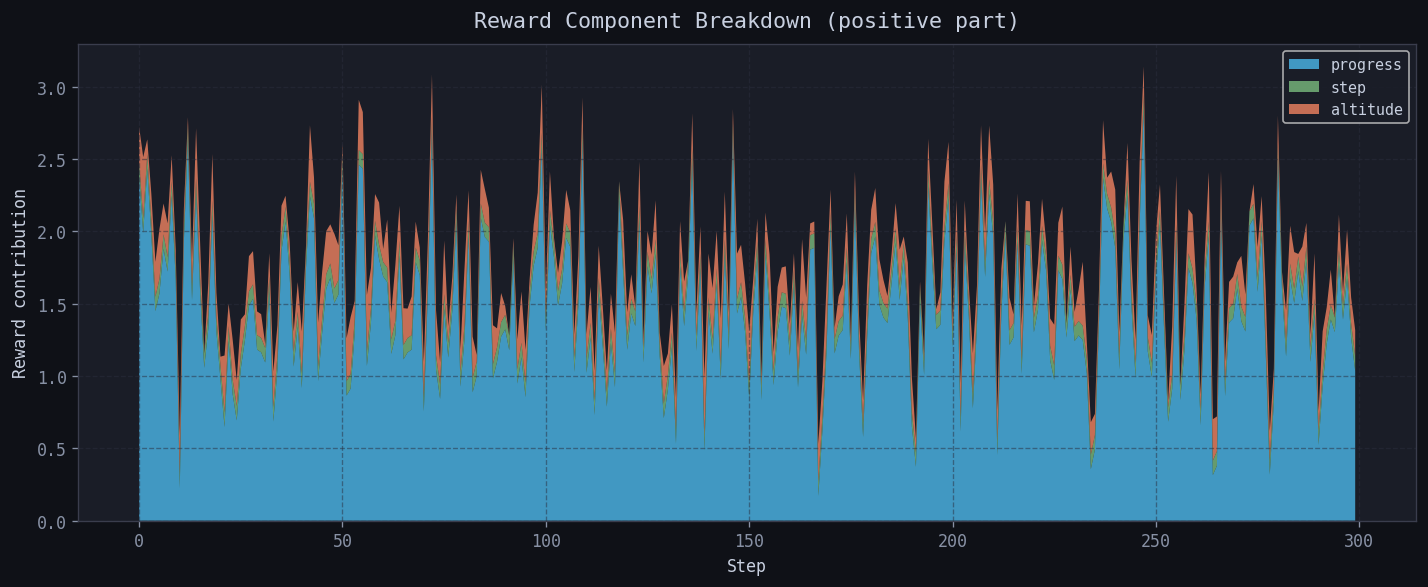

In [5]:
# Ensure plotting helper is available even when cells run out of order
try:
    plot_reward_components
except NameError:
    import sys
from pathlib import Path
cwd = Path.cwd()
if (cwd / "utils").exists():
    root = cwd
elif (cwd.parent / "utils").exists():
    root = cwd.parent
else:
    root = cwd
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.visualization import plot_reward_components

# Synthetic reward components for demonstration
np.random.seed(0)
n_steps = 300
components = [
    {
        'reward/progress':  max(0, np.random.normal(1.5, 0.5)),
        'reward/step':      0.1,
        'reward/altitude':  max(0, np.random.normal(0.2, 0.1)),
    }
    for _ in range(n_steps)
]

fig = plot_reward_components(components)
plt.show()



## 5. 3-D Flight Trajectory

Loaded trajectory with 60 waypoints.


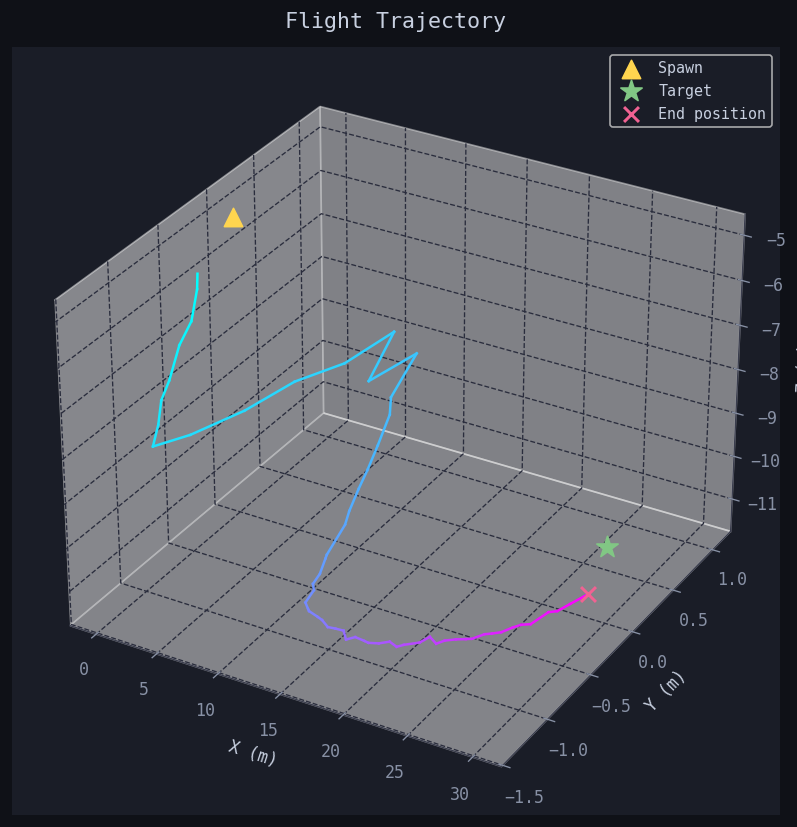

In [6]:
# Ensure plotting helper is available even when cells run out of order
try:
    plot_episode_trajectory
except NameError:
    import sys
from pathlib import Path
cwd = Path.cwd()
if (cwd / "utils").exists():
    root = cwd
elif (cwd.parent / "utils").exists():
    root = cwd.parent
else:
    root = cwd
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.visualization import plot_episode_trajectory

TRAJ_CSV = "../eval_results/trajectories.csv"

try:
    traj_df = pd.read_csv(TRAJ_CSV)
    ep0     = traj_df[traj_df['episode'] == 0]
    positions = list(zip(ep0['x'], ep0['y'], ep0['z']))
    print(f"Loaded trajectory with {len(positions)} waypoints.")
except FileNotFoundError:
    # Synthetic helical path for demonstration
    t = np.linspace(0, 2*np.pi, 200)
    positions = [
        (5*np.cos(s) + s*30/(2*np.pi),
         5*np.sin(s),
         -5 - 3*s/(2*np.pi))
        for s in t
    ]
    print("Using synthetic helical trajectory for demo.")

fig = plot_episode_trajectory(
    positions,
    target=ENV_CONFIG.target_position,
    spawn=ENV_CONFIG.spawn_position,
)
plt.show()



## 6. Distance-Sensor Heat-map

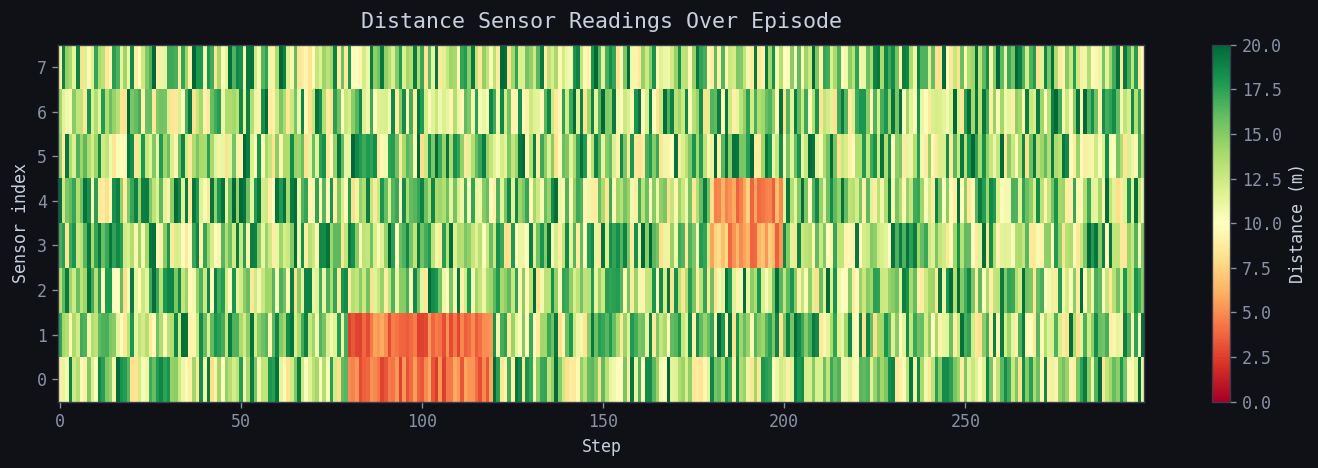

In [7]:
# Ensure plotting helper is available even when cells run out of order
try:
    plot_sensor_heatmap
except NameError:
    import sys
from pathlib import Path
cwd = Path.cwd()
if (cwd / "utils").exists():
    root = cwd
elif (cwd.parent / "utils").exists():
    root = cwd.parent
else:
    root = cwd
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.visualization import plot_sensor_heatmap

np.random.seed(7)
steps, n_sensors = 300, 8
# Simulate sensors decreasing as drone approaches obstacles, then recovering
base = np.random.uniform(8, 20, (steps, n_sensors))
base[80:120, [0, 1]] *= 0.3   # front sensors see an obstacle
base[180:200, [3, 4]] *= 0.4
sensor_history = np.clip(base, 0, 20)

fig = plot_sensor_heatmap(sensor_history, sensor_max=20.0)
plt.show()



## 7. Evaluation Statistics

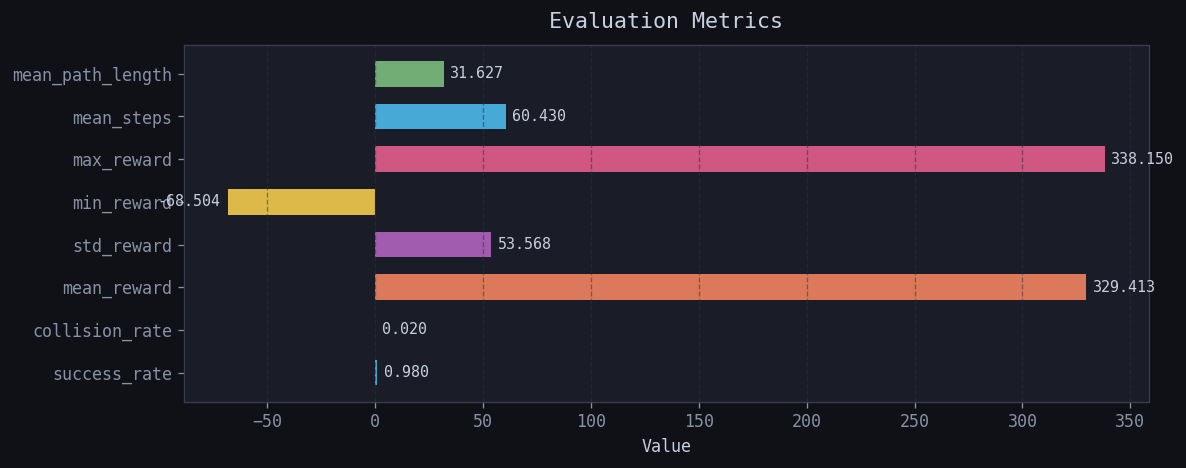


=== Summary ===
  n_episodes                100
  success_rate              0.98
  collision_rate            0.02
  mean_reward               329.4130632049565
  std_reward                53.568289365336845
  min_reward                -68.50431241772021
  max_reward                338.14964292193685
  mean_steps                60.43
  mean_path_length          31.627175098192374


In [8]:
# Ensure plotting helper is available even when cells run out of order
try:
    plot_evaluation_summary
except NameError:
    import sys
from pathlib import Path
cwd = Path.cwd()
if (cwd / "utils").exists():
    root = cwd
elif (cwd.parent / "utils").exists():
    root = cwd.parent
else:
    root = cwd
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.visualization import plot_evaluation_summary

import json

EVAL_JSON = "../eval_results/eval_stats.json"

try:
    with open(EVAL_JSON) as f:
        stats = json.load(f)
except FileNotFoundError:
    # Placeholder stats for demonstration
    stats = {
        'success_rate':     0.72,
        'collision_rate':   0.15,
        'mean_reward':      87.4,
        'std_reward':       22.1,
        'mean_steps':       183.0,
        'mean_path_length': 34.8,
    }
    print("Loaded placeholder statistics.")

fig = plot_evaluation_summary(stats)
plt.show()

print("\n=== Summary ===")
for k, v in stats.items():
    print(f"  {k:<25} {v}")



## 8. Quick Sanity Check — Environment & Policy


In [9]:
from environment.local_env import DroneNavigationEnv
from environment.state_processing import StateProcessor
from environment.reward_function import RewardFunction
from agent.model import DroneActorCritic
import torch

# Instantiate local Gym environment
env = DroneNavigationEnv()
obs, _ = env.reset()
print(f"Observation shape : {obs.shape}")
print(f"Action space      : {env.action_space}")

# Step with a random action
action = env.action_space.sample()
obs2, reward, terminated, truncated, info = env.step(action)
print(f"Step reward       : {reward:.4f}")
print(f"Info keys         : {list(info.keys())}")
env.close()

# Instantiate standalone model
sp = StateProcessor()
model = DroneActorCritic(obs_dim=sp.obs_dim)
print(f"\nPolicy parameters : {model.count_parameters():,}")

dummy_obs = torch.zeros(1, sp.obs_dim)
mean, log_std, value = model(dummy_obs)
print(f"Action mean       : {mean.detach().numpy()}")
print(f"Value estimate    : {value.item():.4f}")

Observation shape : (18,)
Action space      : Box(-1.0, 1.0, (3,), float32)
Step reward       : 0.4263
Info keys         : ['episode_step', 'episode_reward', 'goal_reached', 'collision', 'out_of_bounds', 'reward_breakdown', 'position', 'difficulty_level', 'obstacle_count']

Policy parameters : 137,991
Action mean       : [[0. 0. 0.]]
Value estimate    : 0.0000
